# Site-level LFMM climate scan — Manhattan + QQ (SNP / non-SNP / SV)

**LFMM + GIF calibration.** Honest unit (31 flower-weighted site means), K=3, site-MAF≥0.05. Axes = the signal-bearing ones: bio5, pc1, and the precipitation axes bio12/13/16/19. Manhattans mark per-panel **Bonferroni** (dashed) and **FDR q<0.05** (dotted); the QQ grid shows the per-axis×class calibration.

In [1]:
import sys, os
PROJ='/global/scratch/users/tbellg/kmate'
sys.path.insert(0, f'{PROJ}/analysis/grenenet_gea')
sys.path.insert(0, f'{PROJ}/analysis/grenenet_gea/gea_newpanel')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib as mpl
import scipy.stats as st, lib, blocks_clq09
mpl.rcParams.update({'figure.dpi':110,'font.size':9,'axes.spines.top':False,'axes.spines.right':False})
PCOL='pval_gif'; TAG='LFMM + GIF calibration'
POW=f'{PROJ}/results/grenenet_gea/gea_newpanel/power'
SITE=f'{PROJ}/results/grenenet_gea/gea_newpanel/lfmm_site'
CM=f'{PROJ}/results/grenenet_gea/phase1_replication/class_matrices'
OUT=f'{PROJ}/results/grenenet_gea/gea_newpanel/snp_vs_nonsnp'; os.makedirs(OUT,exist_ok=True)
CHR=[f'Chr{i}' for i in range(1,6)]
CLS=['snp','nonsnp','sv']; NAME={'snp':'SNP','nonsnp':'non-SNP','sv':'SV'}
ACC={'snp':'#c1443c','nonsnp':'#2e7d5b','sv':'#7048a8'}
AXES=['bio5','pc1','bio12','bio13','bio16','bio19']
SUFFIX='_raw' if PCOL=='pval_raw' else ''
_P0={'snp':'p0_snp.npy','nonsnp':'p0_nonsnp.npy','sv':'p0_nonsnp.npy'}
def bh(p):
    p=np.asarray(p,float); n=len(p); o=np.argsort(p); q=np.empty(n)
    q[o]=(p[o]*n)/(np.arange(n)+1); q[o]=np.minimum.accumulate(q[o][::-1])[::-1]; return np.clip(q,0,1)
def gif(p): p=np.clip(np.asarray(p,float),1e-300,1); return np.median(st.chi2.isf(p,1))/st.chi2.isf(0.5,1)

## Load records + site-MAF + genome coords per class

In [2]:
recs={}; mask={}
for c in CLS:
    r=pd.read_csv(f'{CM}/{c}_gen9.records.csv')
    dims=np.loadtxt(f'{SITE}/lfmm_{c}_site_dims.txt',dtype=int); ns,nv=int(dims[0]),int(dims[1])
    dp=np.fromfile(f'{SITE}/lfmm_{c}_site_Y.f64').reshape(ns,nv)
    p0=np.load(f'{lib.AF_STORE}/{_P0[c]}')[r["col"].to_numpy()]
    mf=(dp+p0[None,:]).mean(0); sm=np.minimum(mf,1-mf)
    m=sm>=0.05; mask[c]=m
    rr=r[m].copy(); rr['site_maf']=sm[m]
    rr['block']=blocks_clq09.assign_clq09_blocks(rr.chrom.to_numpy(),rr.pos.to_numpy())
    recs[c]=rr.reset_index(drop=True)
    print(f'{c}: {nv:,} records, MAF>=0.05 -> {m.sum():,}')
chrlen={ch:int(max(recs[c].loc[recs[c].chrom==ch,'pos'].max() if (recs[c].chrom==ch).any() else 0 for c in CLS)) for ch in CHR}
off={}; run=0
for ch in CHR: off[ch]=run; run+=chrlen[ch]+int(2e6)
ticks=[off[ch]+chrlen[ch]/2 for ch in CHR]
for c in CLS: recs[c]['gx']=recs[c].pos.astype(float)+recs[c].chrom.map(off)
def load_p(cls,ax):
    d=pd.read_csv(f'{POW}/exp2_scan_{cls}_{ax}_bothp.csv')[PCOL].to_numpy()
    return d[mask[cls]]

snp: 1,991,825 records, MAF>=0.05 -> 1,948,677


nonsnp: 692,875 records, MAF>=0.05 -> 678,055
sv: 28,260 records, MAF>=0.05 -> 27,194


## Significant clq0.9 BLOCKS per axis — SNP / non-SNP / SV (+ SNP∩SV overlap)
Computed **from this notebook's own p-values** (the same `PCOL` and axes plotted below), site-MAF≥0.05, block = clq0.9 haploblock. So it always matches the Manhattans.

In [3]:
def sig_blocks(cls, axname):
    d=recs[cls].copy(); d['pval']=load_p(cls,axname); d=d[np.isfinite(d.pval)]
    n=len(d); q=bh(d.pval.values)
    bonf=set(d.loc[d.pval < 0.05/n,'block']); fdr=set(d.loc[q < 0.05,'block'])
    bonf.discard(''); fdr.discard(''); return bonf, fdr
SB={ax:{c:sig_blocks(c,ax) for c in CLS} for ax in AXES}
rows=[]
for ax in AXES:
    r={'axis':ax}
    for c in CLS:
        b,f=SB[ax][c]; r[f'{NAME[c]}_Bonf']=len(b); r[f'{NAME[c]}_FDR']=len(f)
    s,v=SB[ax]['snp'],SB[ax]['sv']
    r['SNP∩SV_Bonf']=len(s[0]&v[0]); r['SNP∩SV_FDR']=len(s[1]&v[1])
    rows.append(r)
TBL=pd.DataFrame(rows).set_index('axis')
TBL.to_csv(f'{OUT}/sig_blocks_axis_scan{SUFFIX}.csv')
print(f'Significant clq0.9 BLOCKS — {TAG}, site-MAF>=0.05 (matches the Manhattans below)')
TBL

Significant clq0.9 BLOCKS — LFMM + GIF calibration, site-MAF>=0.05 (matches the Manhattans below)


,SNP_Bonf,SNP_FDR,non-SNP_Bonf,non-SNP_FDR,SV_Bonf,SV_FDR,SNP∩SV_Bonf,SNP∩SV_FDR
axis,,,,,,,,
bio5,0,0,2,2,1,1,0,0
pc1,0,0,1,1,0,0,0,0
bio12,9,53,11,37,6,8,2,5
bio13,14,75,11,55,7,15,2,6
bio16,15,98,18,72,6,15,2,6
bio19,5,58,6,41,3,12,0,5


## QQ grid — calibration per axis × class (LFMM + GIF calibration)
Observed vs expected −log10 p under the uniform null; GIF (λ) annotated. Points above the diagonal = inflation.

wrote qq_axis_scan.png


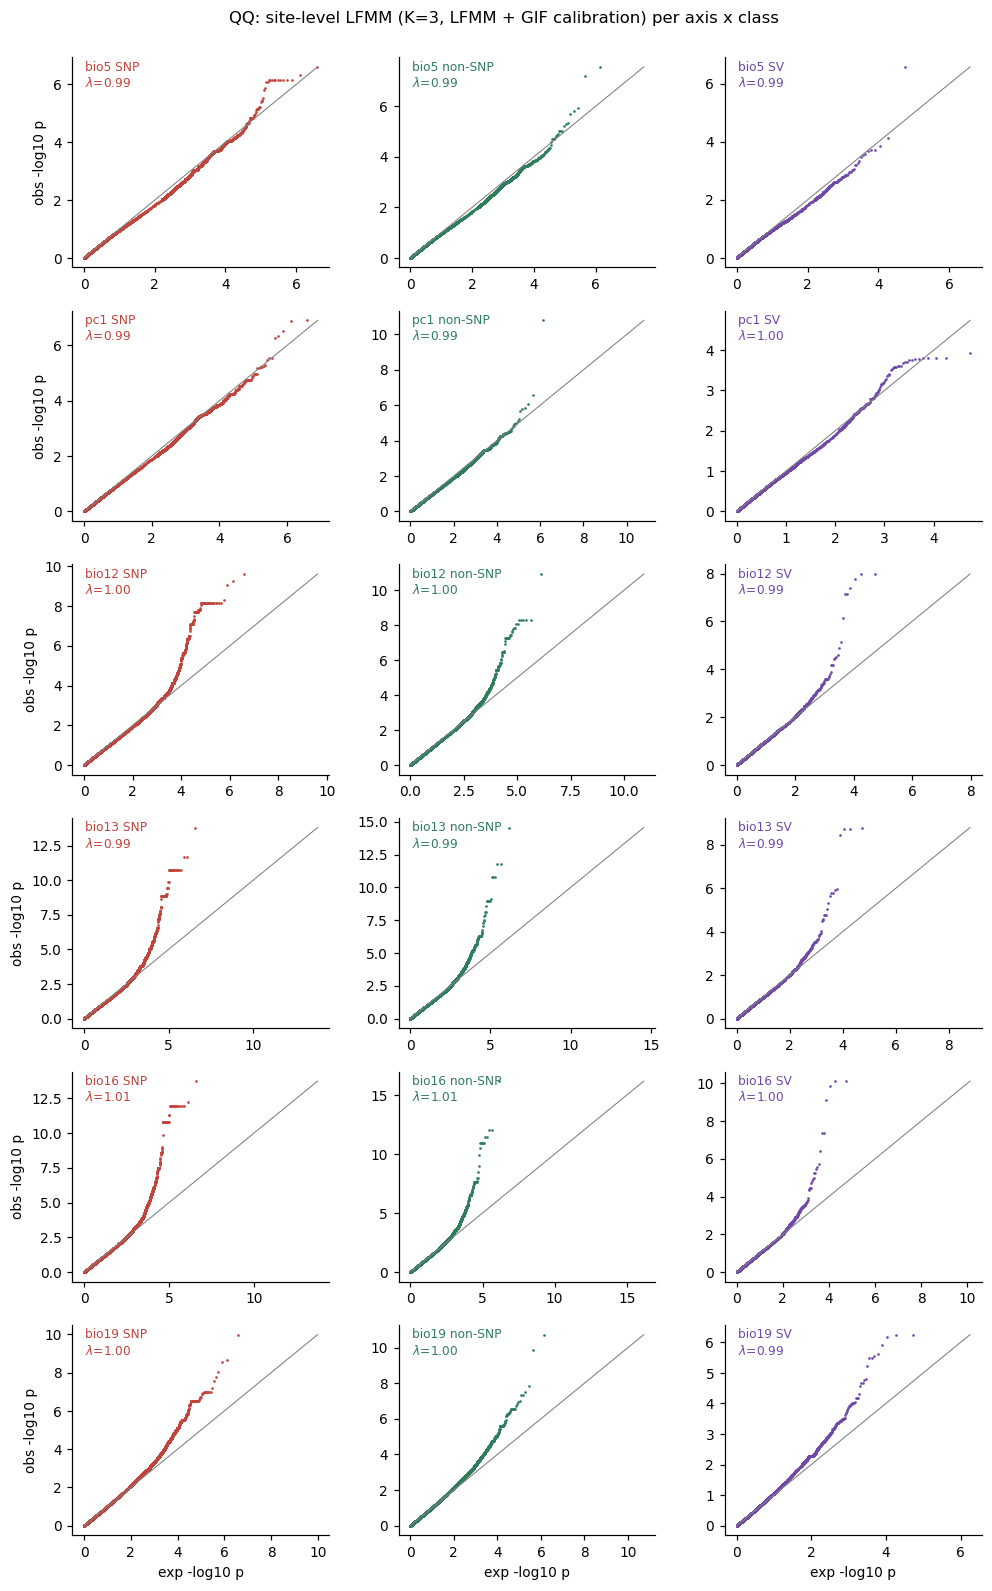

In [4]:
def qq(ax_, p, color, lab):
    p=np.sort(np.asarray(p,float)); p=p[np.isfinite(p)]; n=len(p)
    obs=-np.log10(np.clip(p,1e-300,1)); exp=-np.log10((np.arange(1,n+1)-0.5)/n)
    keep=np.concatenate([np.where(obs>2)[0], np.random.RandomState(0).choice(np.where(obs<=2)[0], size=min(4000,int((obs<=2).sum())), replace=False)])
    keep=np.sort(keep)
    ax_.scatter(exp[keep],obs[keep],s=3,c=color,rasterized=True,linewidths=0)
    m=max(exp.max(),obs.max()); ax_.plot([0,m],[0,m],lw=0.7,color='0.5')
    ax_.text(0.05,0.86,f'{lab}\n$\\lambda$={gif(p):.2f}',transform=ax_.transAxes,fontsize=8,color=color)
fig,axes=plt.subplots(len(AXES),3,figsize=(9,2.4*len(AXES)))
for i,axname in enumerate(AXES):
    for j,c in enumerate(CLS):
        qq(axes[i,j], load_p(c,axname), ACC[c], f'{axname} {NAME[c]}')
        if j==0: axes[i,j].set_ylabel('obs -log10 p')
        if i==len(AXES)-1: axes[i,j].set_xlabel('exp -log10 p')
fig.suptitle(f'QQ: site-level LFMM (K=3, {TAG}) per axis x class',y=1.0)
fig.tight_layout(); fig.savefig(f'{OUT}/qq_axis_scan{SUFFIX}.png',dpi=140,bbox_inches='tight')
print('wrote', f'qq_axis_scan{SUFFIX}.png'); plt.show()

## Manhattans per axis — SNP / non-SNP / SV, with Bonferroni + FDR lines

In [5]:
cols={'Chr1':'#3b5b92','Chr2':'#8bb0d0','Chr3':'#3b5b92','Chr4':'#8bb0d0','Chr5':'#3b5b92'}
def manhattan_axis(axname):
    fig,axs=plt.subplots(3,1,figsize=(13,7.5),sharex=True)
    for ax_,c in zip(axs,CLS):
        d=recs[c].copy(); d['pval']=load_p(c,axname); d=d[np.isfinite(d.pval)]
        d['nlp']=-np.log10(d.pval.clip(1e-300)); pv=d.pval.to_numpy(); nt=len(pv)
        bonf=-np.log10(0.05/nt); pas=pv[bh(pv)<0.05]; fdr=(-np.log10(pas.max())) if pas.size else None
        base=d.sample(frac=min(1.0,200000/len(d)),random_state=0) if len(d)>200000 else d
        t=pd.concat([base,d[d.nlp>2]]).drop_duplicates(subset=['gx','nlp'])
        ax_.scatter(t.gx,t.nlp,s=3,c=t.chrom.map(cols),rasterized=True,linewidths=0)
        ax_.axhline(bonf,ls='--',lw=1.0,color='#444',label=f'Bonferroni ({bonf:.1f})')
        if fdr is not None: ax_.axhline(fdr,ls=':',lw=1.3,color='#b8860b',label=f'FDR q<.05 ({fdr:.1f})')
        else: ax_.plot([],[],' ',label='FDR q<.05: none')
        top=d.nlargest(1,'nlp').iloc[0]
        ax_.scatter([top.gx],[top.nlp],s=40,facecolors='none',edgecolors=ACC[c],linewidths=1.5,zorder=5)
        ax_.annotate(f'{top.chrom}:{int(top.pos):,} {top.block}',(top.gx,top.nlp),xytext=(6,-1),
                     textcoords='offset points',fontsize=7.5,color=ACC[c])
        ax_.set_ylabel('-log10 p'); ax_.set_ylim(-0.4,max(float(d.nlp.max()),bonf)*1.10)
        ax_.text(0.995,0.86,NAME[c],transform=ax_.transAxes,ha='right',fontweight='bold',color=ACC[c])
        ax_.legend(loc='upper left',fontsize=7,frameon=False)
    axs[2].set_xticks(ticks); axs[2].set_xticklabels(CHR); axs[2].set_xlabel('genome position')
    lam=' | '.join(f'{NAME[c]} λ={gif(load_p(c,axname)):.2f}' for c in CLS)
    fig.suptitle(f'{axname} — site-level LFMM ({TAG})   [{lam}]',y=0.995)
    fig.tight_layout(); fn=f'manhattan_{axname}_snp_nonsnp_sv{SUFFIX}.png'
    fig.savefig(f'{OUT}/{fn}',dpi=140,bbox_inches='tight'); print('wrote',fn); plt.show()

### bio5

wrote manhattan_bio5_snp_nonsnp_sv.png


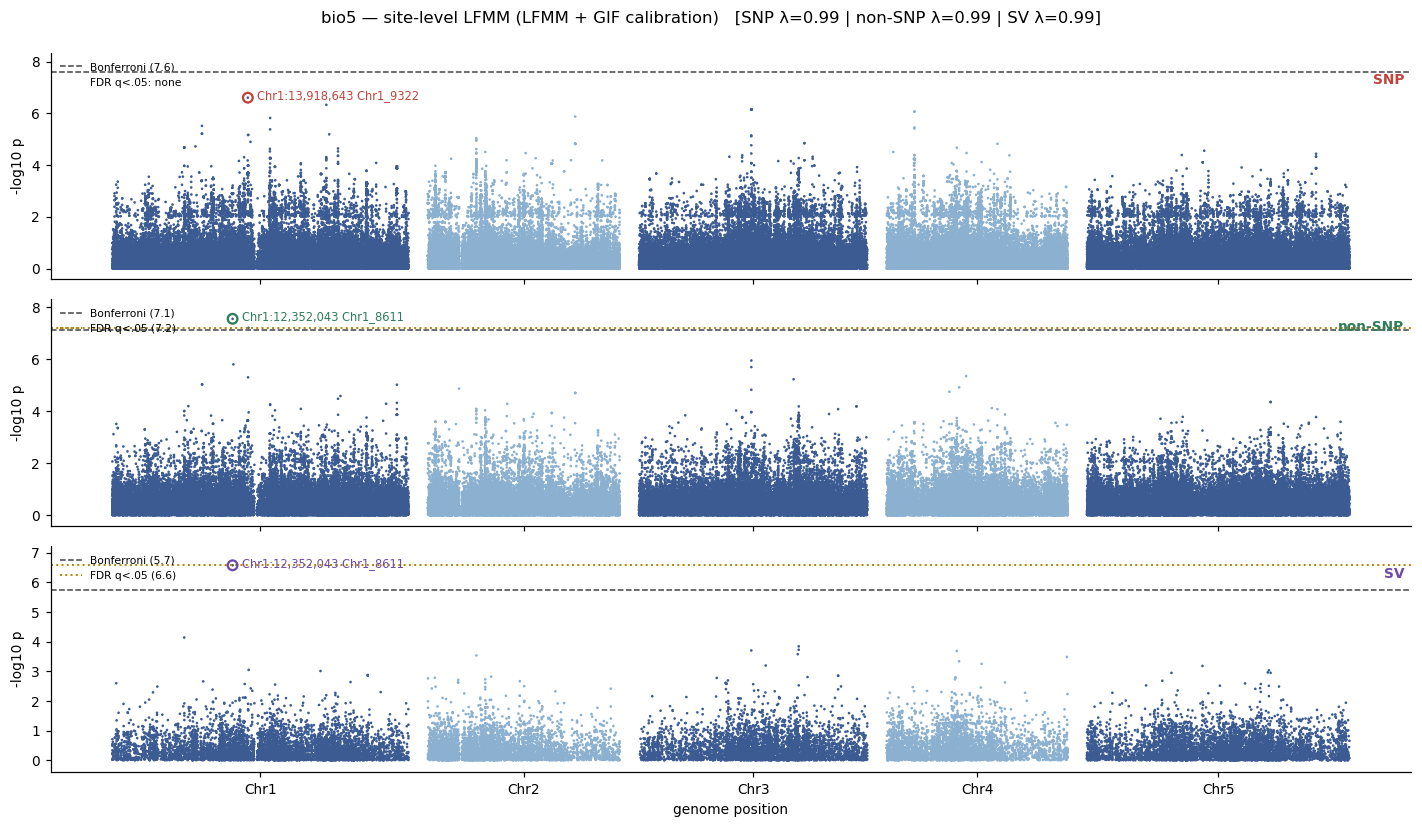

In [6]:
manhattan_axis('bio5')

### pc1

wrote manhattan_pc1_snp_nonsnp_sv.png


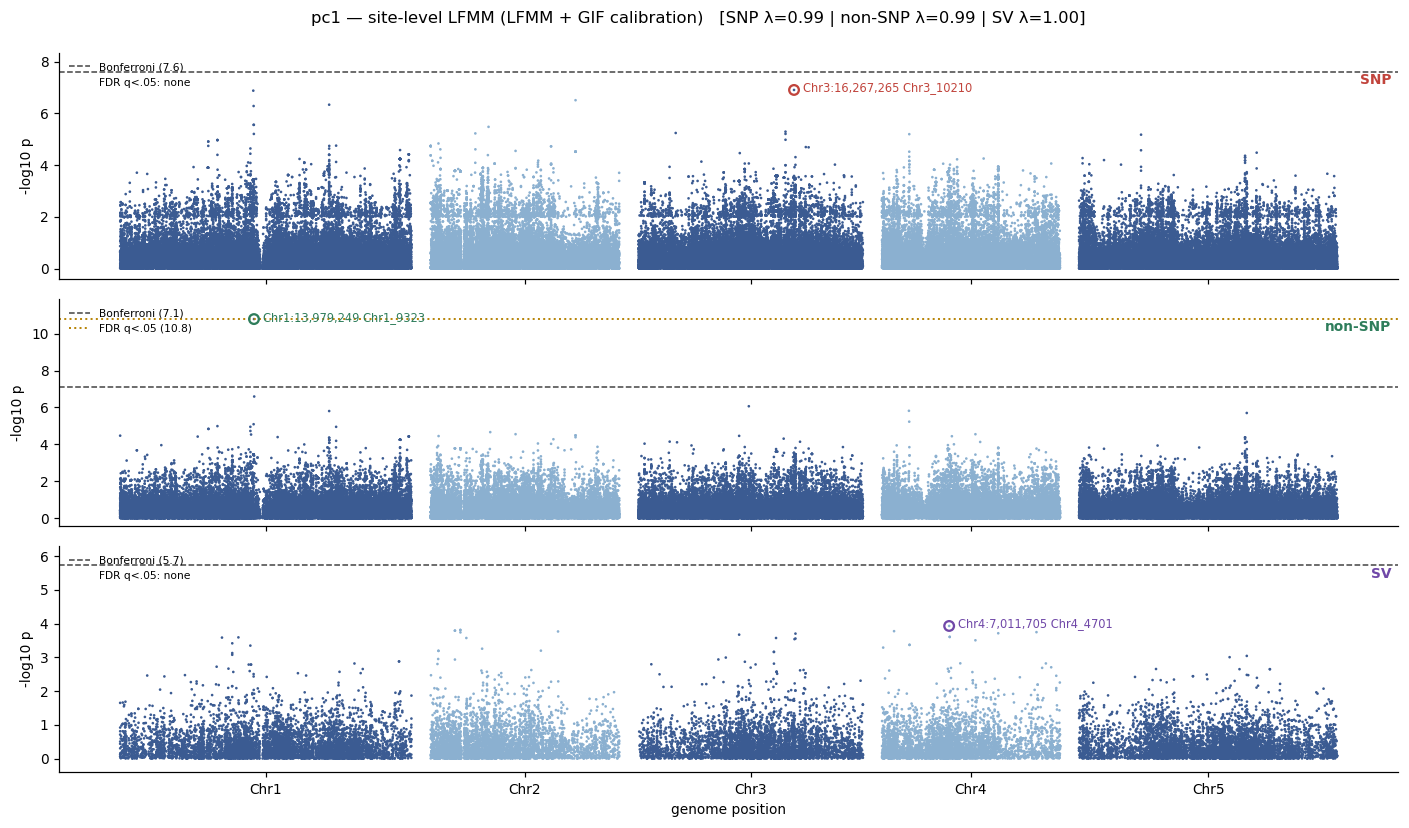

In [7]:
manhattan_axis('pc1')

### bio12

wrote manhattan_bio12_snp_nonsnp_sv.png


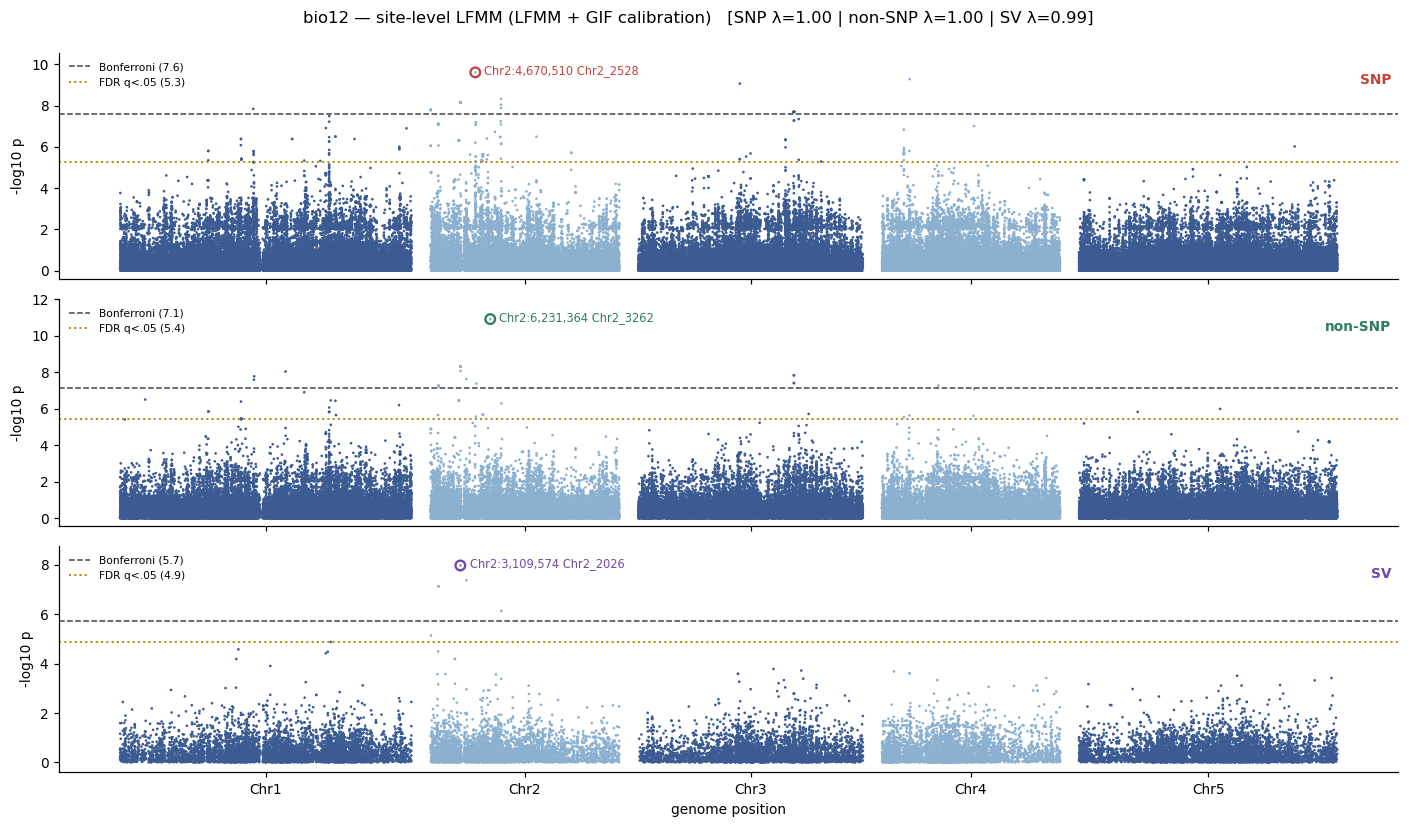

In [8]:
manhattan_axis('bio12')

### bio13

wrote manhattan_bio13_snp_nonsnp_sv.png


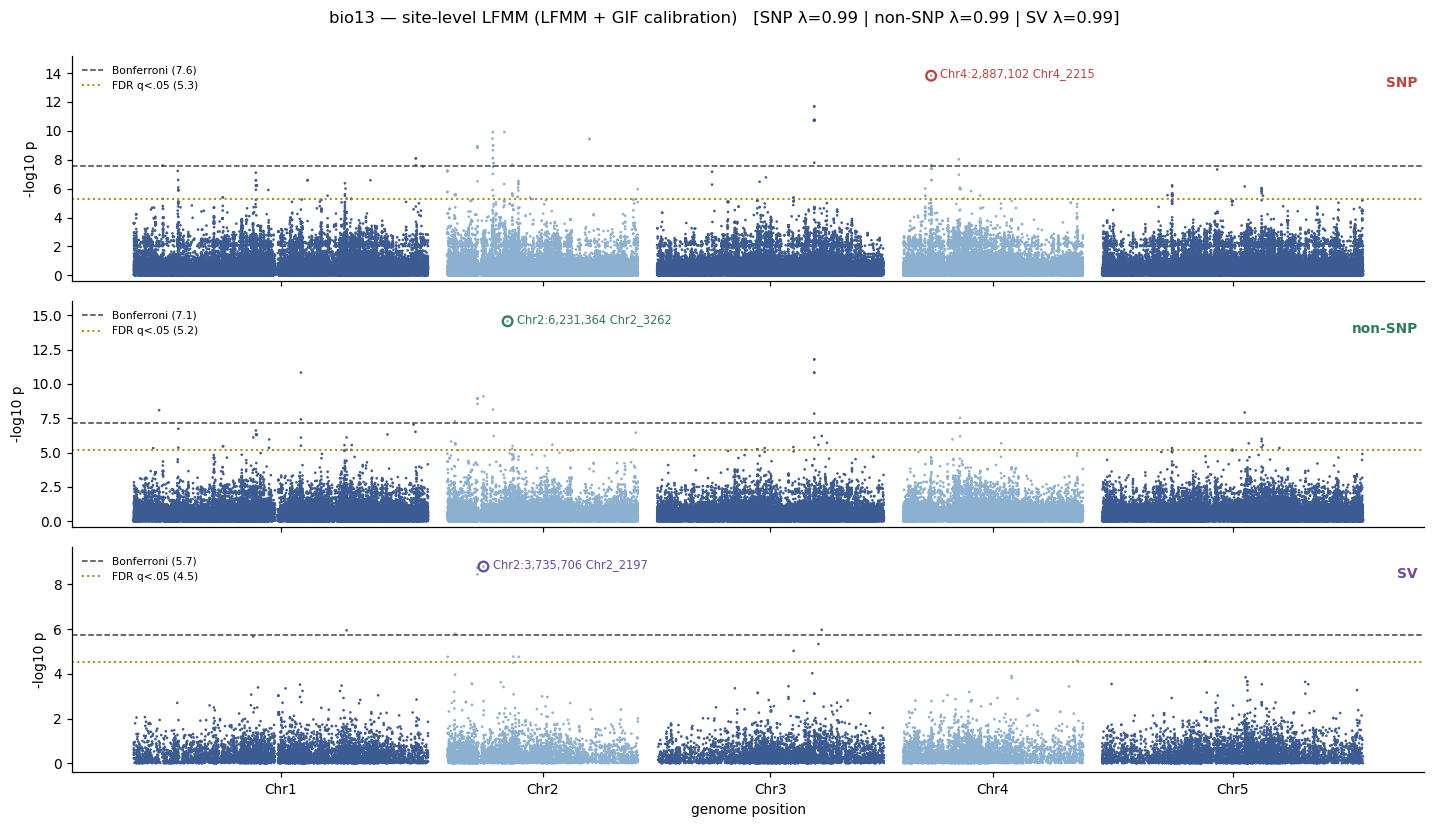

In [9]:
manhattan_axis('bio13')

### bio16

wrote manhattan_bio16_snp_nonsnp_sv.png


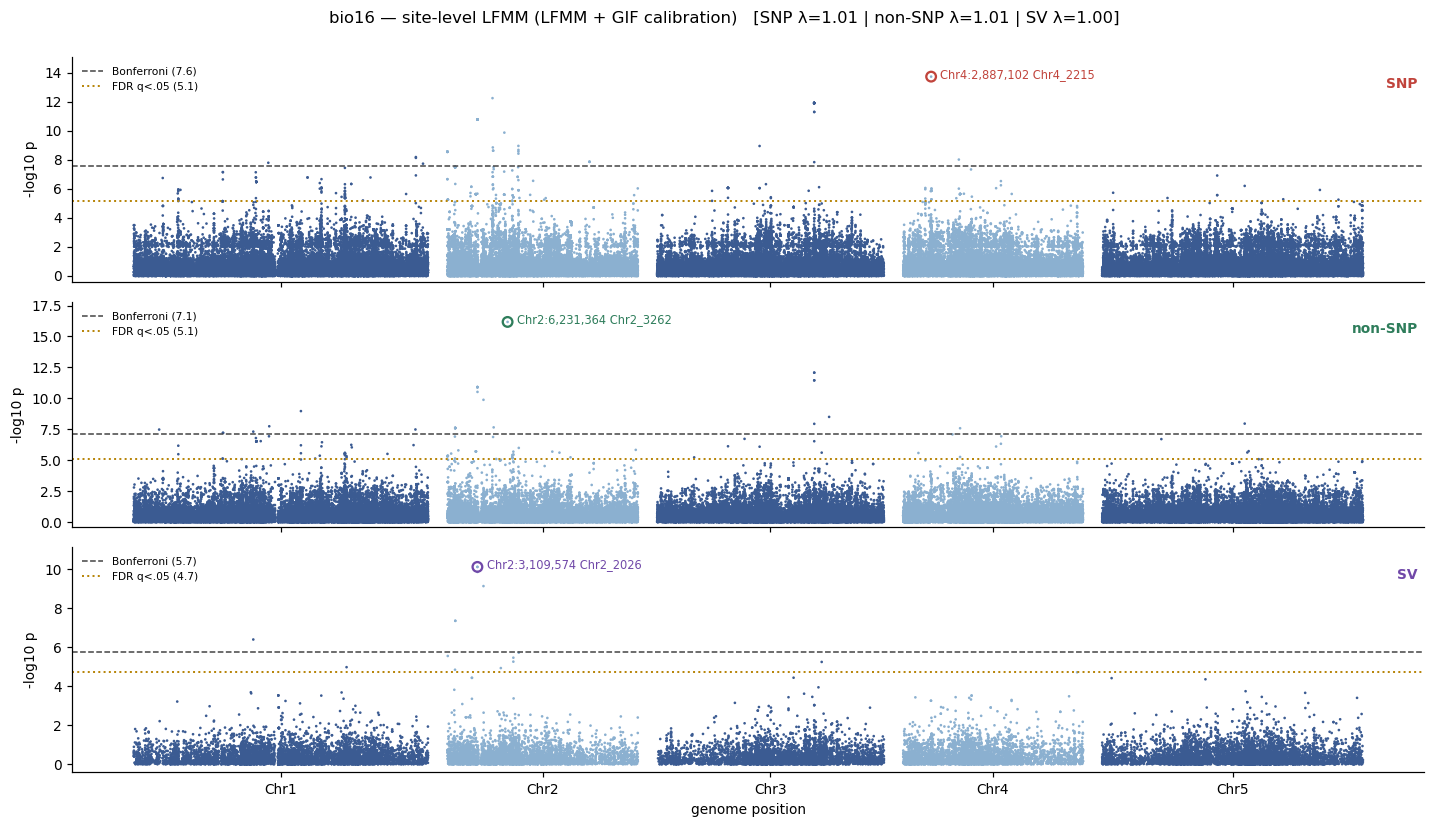

In [10]:
manhattan_axis('bio16')

### bio19

wrote manhattan_bio19_snp_nonsnp_sv.png


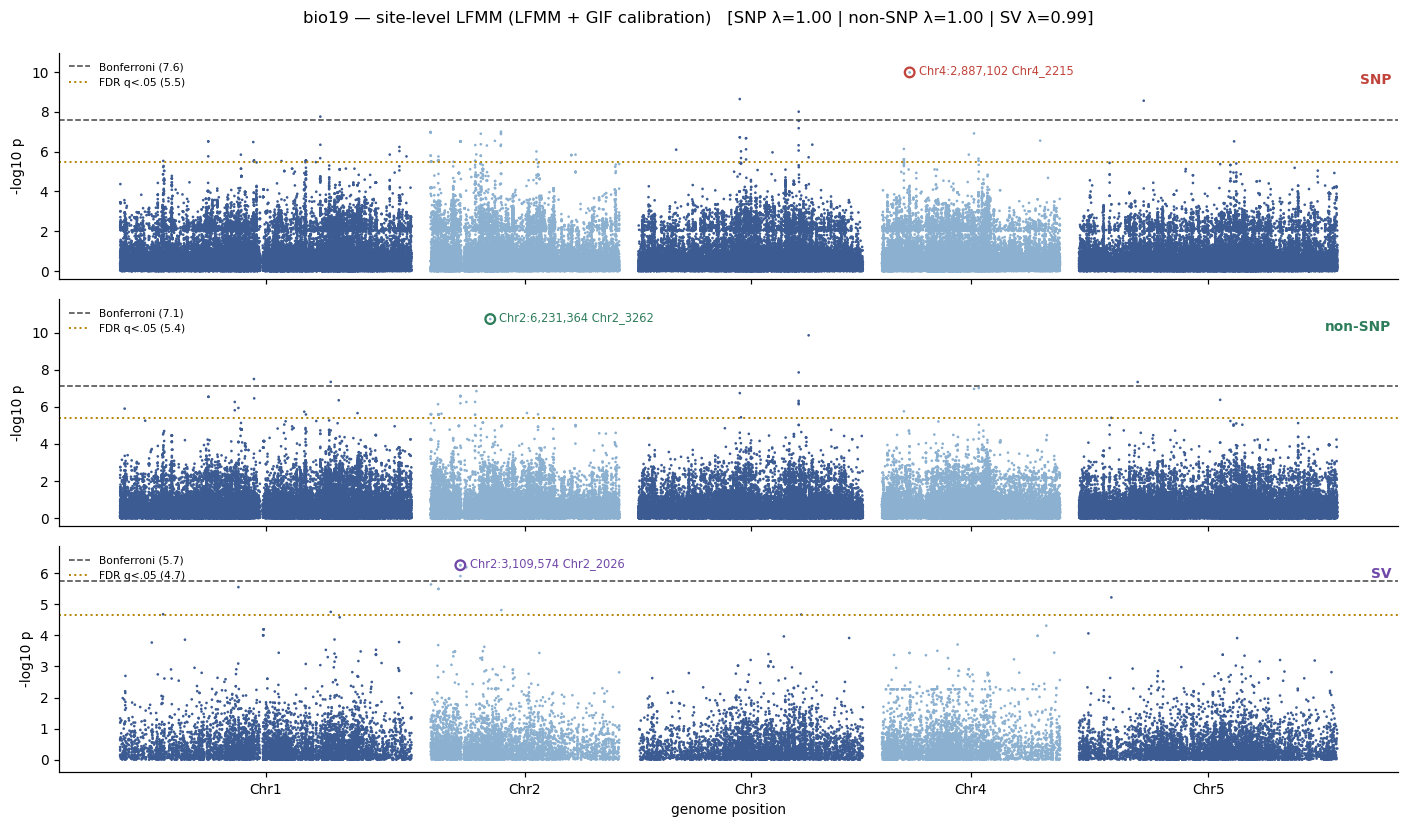

In [11]:
manhattan_axis('bio19')